# Анализ и исследование данных

Этот ноутбук выполняет исследовательский анализ датасета CVC-ClinicDB: просмотр изображений, масок, распределение размеров полипов и визуализация аугментаций.

In [2]:
import sys
sys.path.append('../src')

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Библиотеки загружены")
print(f"OpenCV версия: {cv2.__version__}")

Библиотеки загружены
OpenCV версия: 4.13.0


## 1. Загрузка датасета

In [3]:
# Пути к данным
img_dir = '../data/CVC-ClinicDB/images'
mask_dir = '../data/CVC-ClinicDB/annotations'

# Проверка существования папок
if os.path.exists(img_dir):
    images = [f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"✅ Папка с изображениями: {img_dir}")
    print(f"   Найдено изображений: {len(images)}")
else:
    print(f"❌ Папка не найдена: {img_dir}")

if os.path.exists(mask_dir):
    masks = [f for f in os.listdir(mask_dir) if f.endswith('.png')]
    print(f"✅ Папка с масками: {mask_dir}")
    print(f"   Найдено масок: {len(masks)}")
else:
    print(f"❌ Папка не найдена: {mask_dir}")

✅ Папка с изображениями: ../data/CVC-ClinicDB/images
   Найдено изображений: 612
✅ Папка с масками: ../data/CVC-ClinicDB/annotations
   Найдено масок: 612


## 2. Просмотр примеров изображений и масок

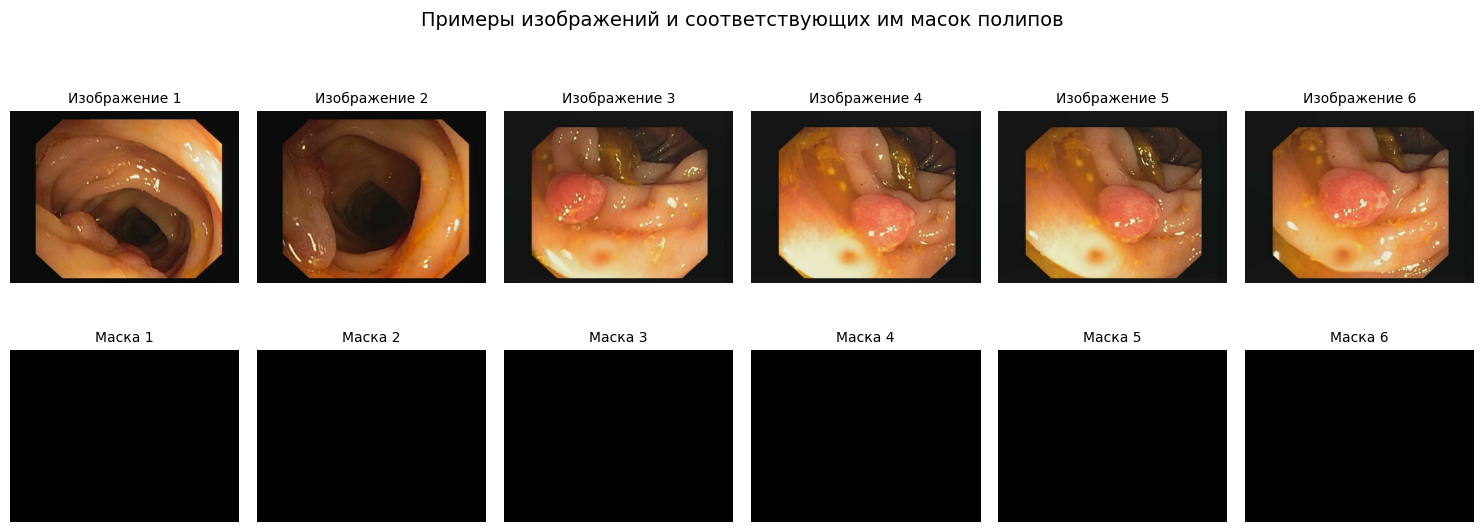

✅ Сохранено: reports/sample_images_and_masks.png


In [4]:
# Получаем список файлов
image_files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])

# Выбираем первые 6 изображений для просмотра
num_samples = min(6, len(image_files))
selected_images = image_files[:num_samples]

fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

for idx, img_name in enumerate(selected_images):
    # Загрузка изображения
    img_path = os.path.join(img_dir, img_name)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Загрузка маски
    base_name = os.path.splitext(img_name)[0]
    mask_name = base_name + '.png'
    mask_path = os.path.join(mask_dir, mask_name)
    
    if os.path.exists(mask_path):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    else:
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
    
    # Отображение изображения
    axes[0, idx].imshow(image)
    axes[0, idx].set_title(f'Изображение {idx+1}', fontsize=10)
    axes[0, idx].axis('off')
    
    # Отображение маски
    axes[1, idx].imshow(mask, cmap='gray')
    axes[1, idx].set_title(f'Маска {idx+1}', fontsize=10)
    axes[1, idx].axis('off')

plt.suptitle('Примеры изображений и соответствующих им масок полипов', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/sample_images_and_masks.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: reports/sample_images_and_masks.png")

## 3. Анализ размеров изображений

In [5]:
# Сбор информации о размерах
widths = []
heights = []
aspect_ratios = []

for img_name in image_files[:100]:  # Анализируем первые 100 для скорости
    img_path = os.path.join(img_dir, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)
        aspect_ratios.append(w / h)

print("=" * 50)
print("СТАТИСТИКА РАЗМЕРОВ ИЗОБРАЖЕНИЙ")
print("=" * 50)
print(f"Ширина - мин: {np.min(widths):.0f}, макс: {np.max(widths):.0f}, средняя: {np.mean(widths):.0f}")
print(f"Высота  - мин: {np.min(heights):.0f}, макс: {np.max(heights):.0f}, средняя: {np.mean(heights):.0f}")
print(f"Соотношение сторон - мин: {np.min(aspect_ratios):.2f}, макс: {np.max(aspect_ratios):.2f}, среднее: {np.mean(aspect_ratios):.2f}")

СТАТИСТИКА РАЗМЕРОВ ИЗОБРАЖЕНИЙ
Ширина - мин: 384, макс: 384, средняя: 384
Высота  - мин: 288, макс: 288, средняя: 288
Соотношение сторон - мин: 1.33, макс: 1.33, среднее: 1.33


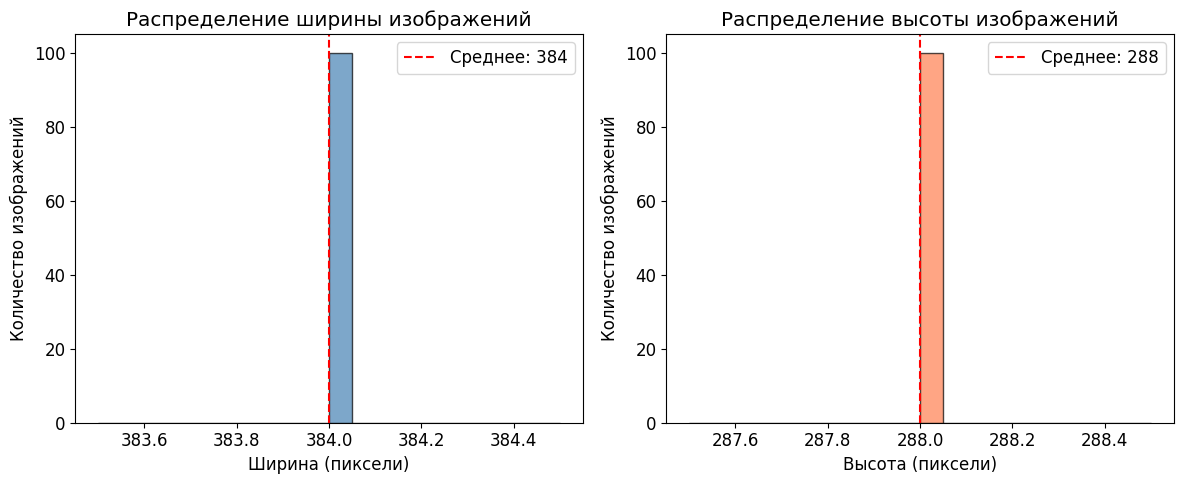

✅ Сохранено: reports/image_size_distribution.png


In [6]:
# График распределения размеров
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Распределение ширин
axes[0].hist(widths, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Ширина (пиксели)')
axes[0].set_ylabel('Количество изображений')
axes[0].set_title('Распределение ширины изображений')
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Среднее: {np.mean(widths):.0f}')
axes[0].legend()

# Распределение высот
axes[1].hist(heights, bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Высота (пиксели)')
axes[1].set_ylabel('Количество изображений')
axes[1].set_title('Распределение высоты изображений')
axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Среднее: {np.mean(heights):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: reports/image_size_distribution.png")

## 4. Анализ размеров полипов

In [7]:
# Функция для поиска bounding box по маске
def get_polyp_size(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    
    # Находим ненулевые пиксели (полип)
    y_indices, x_indices = np.where(mask > 50)
    if len(y_indices) == 0:
        return None
    
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    
    width = x_max - x_min
    height = y_max - y_min
    area = width * height
    
    return {'width': width, 'height': height, 'area': area}

# Анализируем все маски
polyp_widths = []
polyp_heights = []
polyp_areas = []

mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]

for mask_name in mask_files[:200]:  # Первые 200 для скорости
    mask_path = os.path.join(mask_dir, mask_name)
    size = get_polyp_size(mask_path)
    if size:
        polyp_widths.append(size['width'])
        polyp_heights.append(size['height'])
        polyp_areas.append(size['area'])

print("=" * 50)
print("СТАТИСТИКА РАЗМЕРОВ ПОЛИПОВ")
print("=" * 50)
print(f"Ширина - мин: {np.min(polyp_widths):.0f}, макс: {np.max(polyp_widths):.0f}, средняя: {np.mean(polyp_widths):.0f}")
print(f"Высота  - мин: {np.min(polyp_heights):.0f}, макс: {np.max(polyp_heights):.0f}, средняя: {np.mean(polyp_heights):.0f}")
print(f"Площадь - мин: {np.min(polyp_areas):.0f}, макс: {np.max(polyp_areas):.0f}, средняя: {np.mean(polyp_areas):.0f}")

СТАТИСТИКА РАЗМЕРОВ ПОЛИПОВ
Ширина - мин: 80, макс: 80, средняя: 80
Высота  - мин: 51, макс: 80, средняя: 76
Площадь - мин: 4080, макс: 6400, средняя: 6041


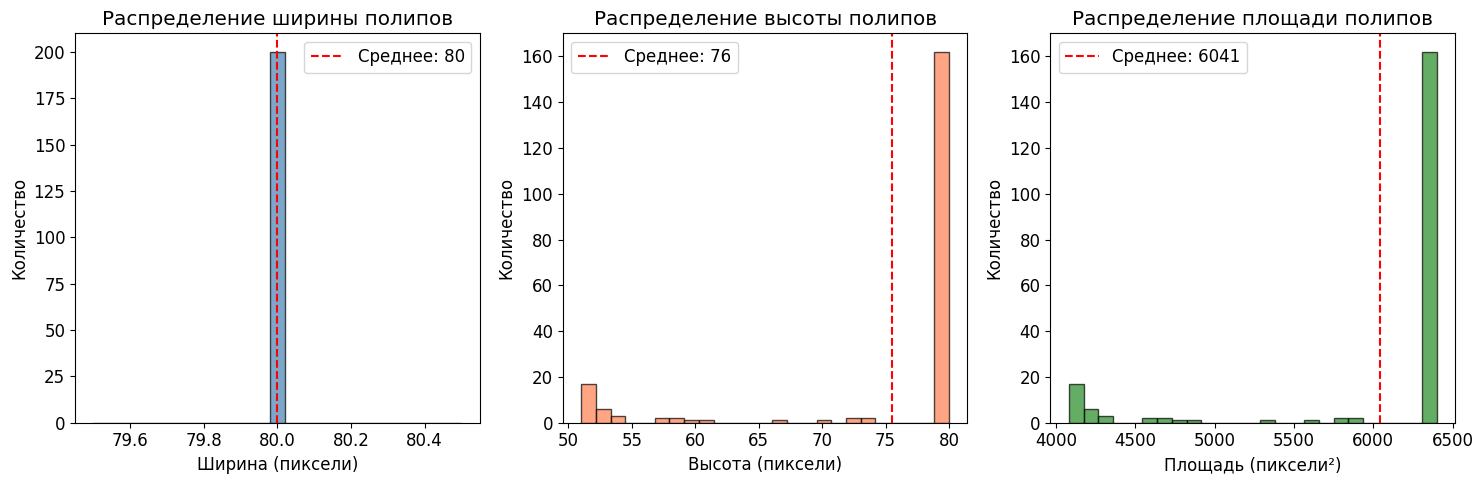

✅ Сохранено: reports/polyp_size_distribution.png


In [8]:
# График распределения размеров полипов
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ширина
axes[0].hist(polyp_widths, bins=25, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Ширина (пиксели)')
axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение ширины полипов')
axes[0].axvline(np.mean(polyp_widths), color='red', linestyle='--', label=f'Среднее: {np.mean(polyp_widths):.0f}')
axes[0].legend()

# Высота
axes[1].hist(polyp_heights, bins=25, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Высота (пиксели)')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение высоты полипов')
axes[1].axvline(np.mean(polyp_heights), color='red', linestyle='--', label=f'Среднее: {np.mean(polyp_heights):.0f}')
axes[1].legend()

# Площадь
axes[2].hist(polyp_areas, bins=25, color='forestgreen', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Площадь (пиксели²)')
axes[2].set_ylabel('Количество')
axes[2].set_title('Распределение площади полипов')
axes[2].axvline(np.mean(polyp_areas), color='red', linestyle='--', label=f'Среднее: {np.mean(polyp_areas):.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/polyp_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: reports/polyp_size_distribution.png")

## 5. Визуализация аугментации данных

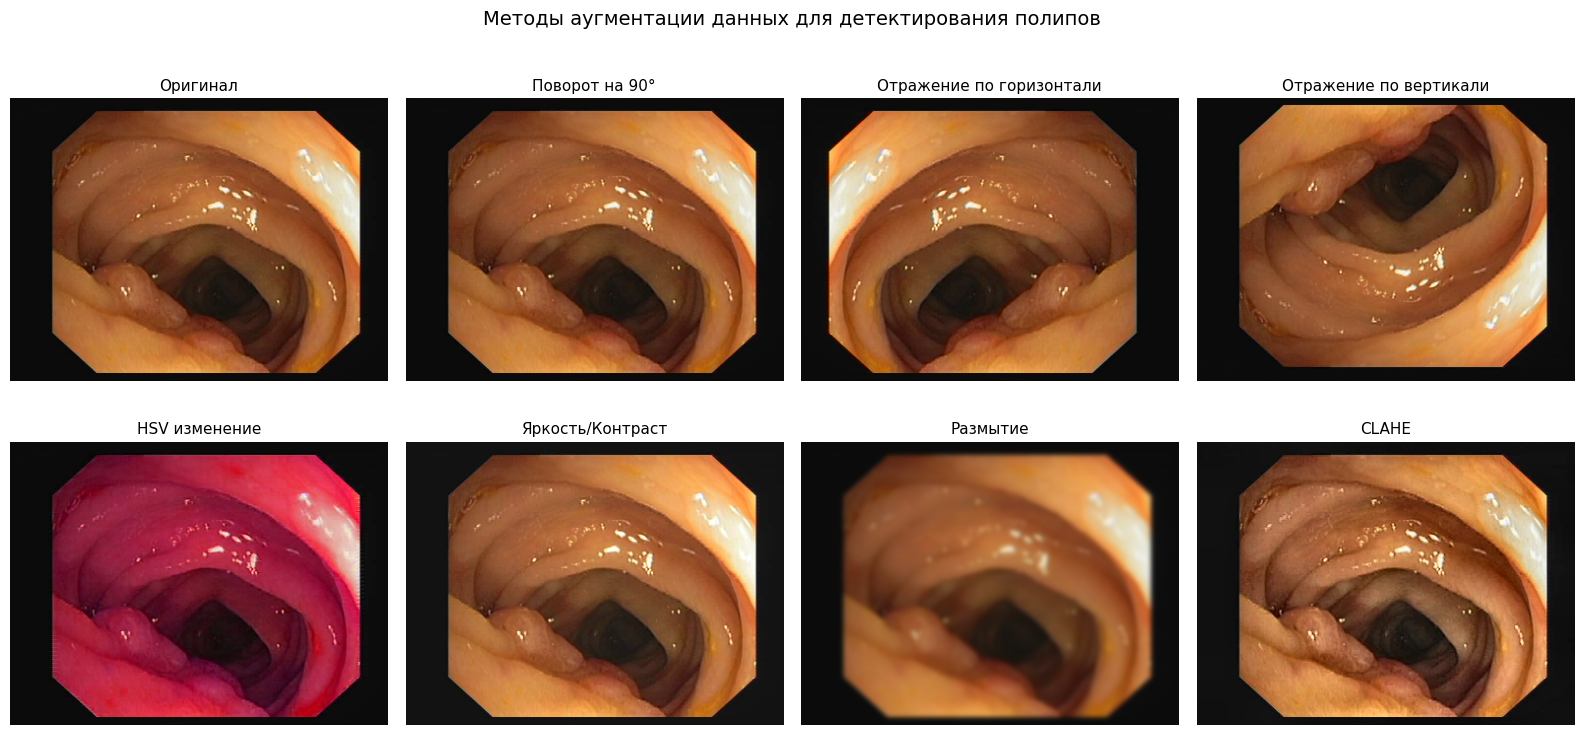

✅ Сохранено: reports/augmentation_visualization.png


In [9]:
# Загружаем пример изображения
sample_img_path = os.path.join(img_dir, image_files[0])
original_image = cv2.imread(sample_img_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Определяем аугментации
augmentations = [
    ("Оригинал", None),
    ("Поворот на 90°", A.RandomRotate90(p=1.0)),
    ("Отражение по горизонтали", A.HorizontalFlip(p=1.0)),
    ("Отражение по вертикали", A.VerticalFlip(p=1.0)),
    ("HSV изменение", A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=30, p=1.0)),
    ("Яркость/Контраст", A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0)),
    ("Размытие", A.GaussianBlur(blur_limit=3, p=1.0)),
    ("CLAHE", A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0))
]

# Отображение
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (title, aug) in enumerate(augmentations):
    if aug is None:
        augmented = original_image
    else:
        augmented = aug(image=original_image)['image']
    
    axes[idx].imshow(augmented)
    axes[idx].set_title(title, fontsize=11)
    axes[idx].axis('off')

plt.suptitle('Методы аугментации данных для детектирования полипов', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/augmentation_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: reports/augmentation_visualization.png")


## 6. Визуализация HSV преобразований

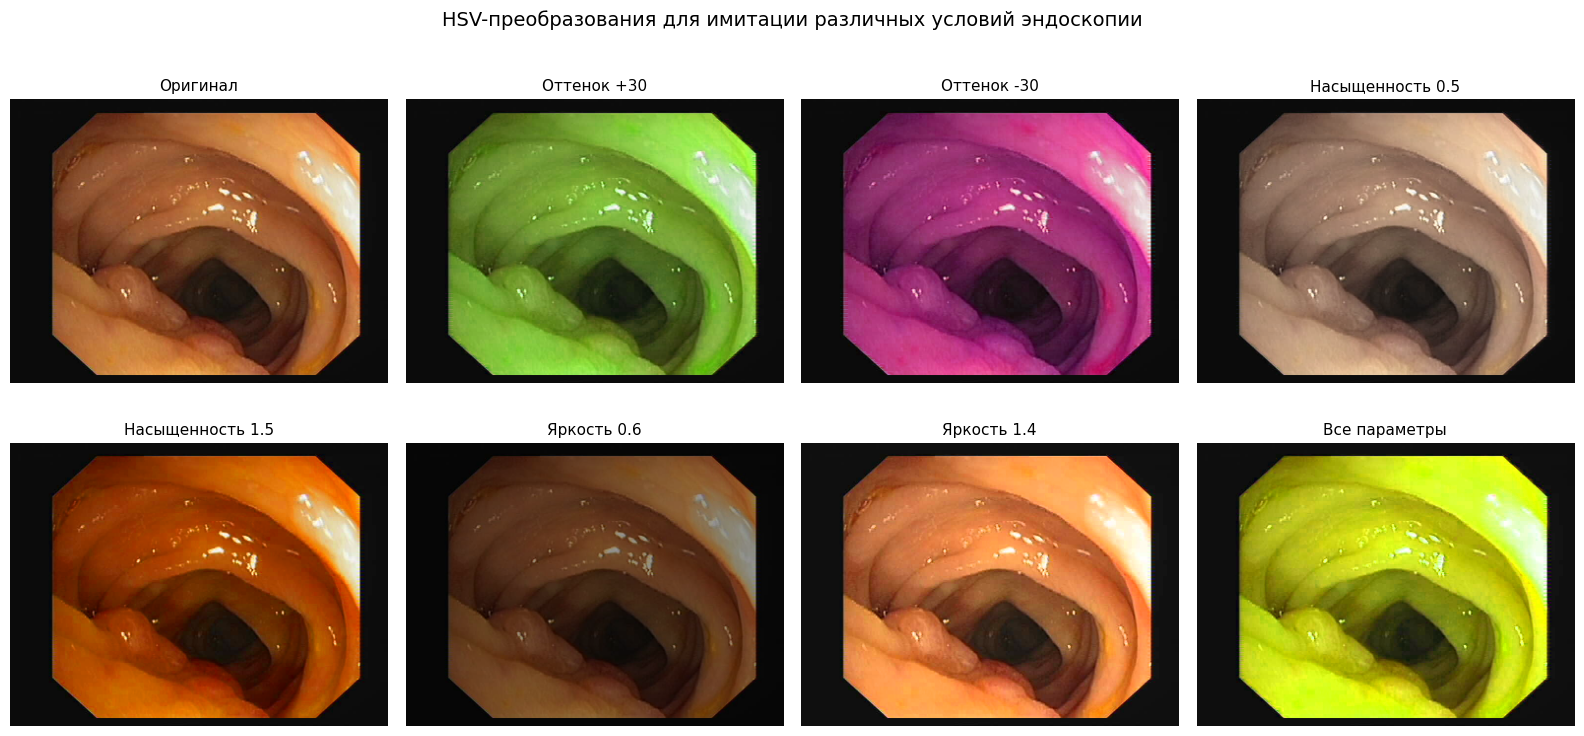

✅ Сохранено: reports/hsv_augmentation.png


In [10]:
# Преобразование в HSV
image_hsv = cv2.cvtColor(original_image, cv2.COLOR_RGB2HSV)

# Вариации HSV
variations = [
    ("Оригинал", (0, 1, 1)),
    ("Оттенок +30", (30, 1, 1)),
    ("Оттенок -30", (-30, 1, 1)),
    ("Насыщенность 0.5", (0, 0.5, 1)),
    ("Насыщенность 1.5", (0, 1.5, 1)),
    ("Яркость 0.6", (0, 1, 0.6)),
    ("Яркость 1.4", (0, 1, 1.4)),
    ("Все параметры", (20, 1.3, 1.3))
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (title, (h_shift, s_scale, v_scale)) in enumerate(variations):
    hsv_copy = image_hsv.copy().astype(np.float32)
    hsv_copy[:, :, 0] = (hsv_copy[:, :, 0] + h_shift) % 180
    hsv_copy[:, :, 1] = np.clip(hsv_copy[:, :, 1] * s_scale, 0, 255)
    hsv_copy[:, :, 2] = np.clip(hsv_copy[:, :, 2] * v_scale, 0, 255)
    hsv_copy = hsv_copy.astype(np.uint8)
    
    result = cv2.cvtColor(hsv_copy, cv2.COLOR_HSV2RGB)
    
    axes[idx].imshow(result)
    axes[idx].set_title(title, fontsize=11)
    axes[idx].axis('off')

plt.suptitle('HSV-преобразования для имитации различных условий эндоскопии', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/hsv_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: reports/hsv_augmentation.png")

## 7. Наложение масок на изображения

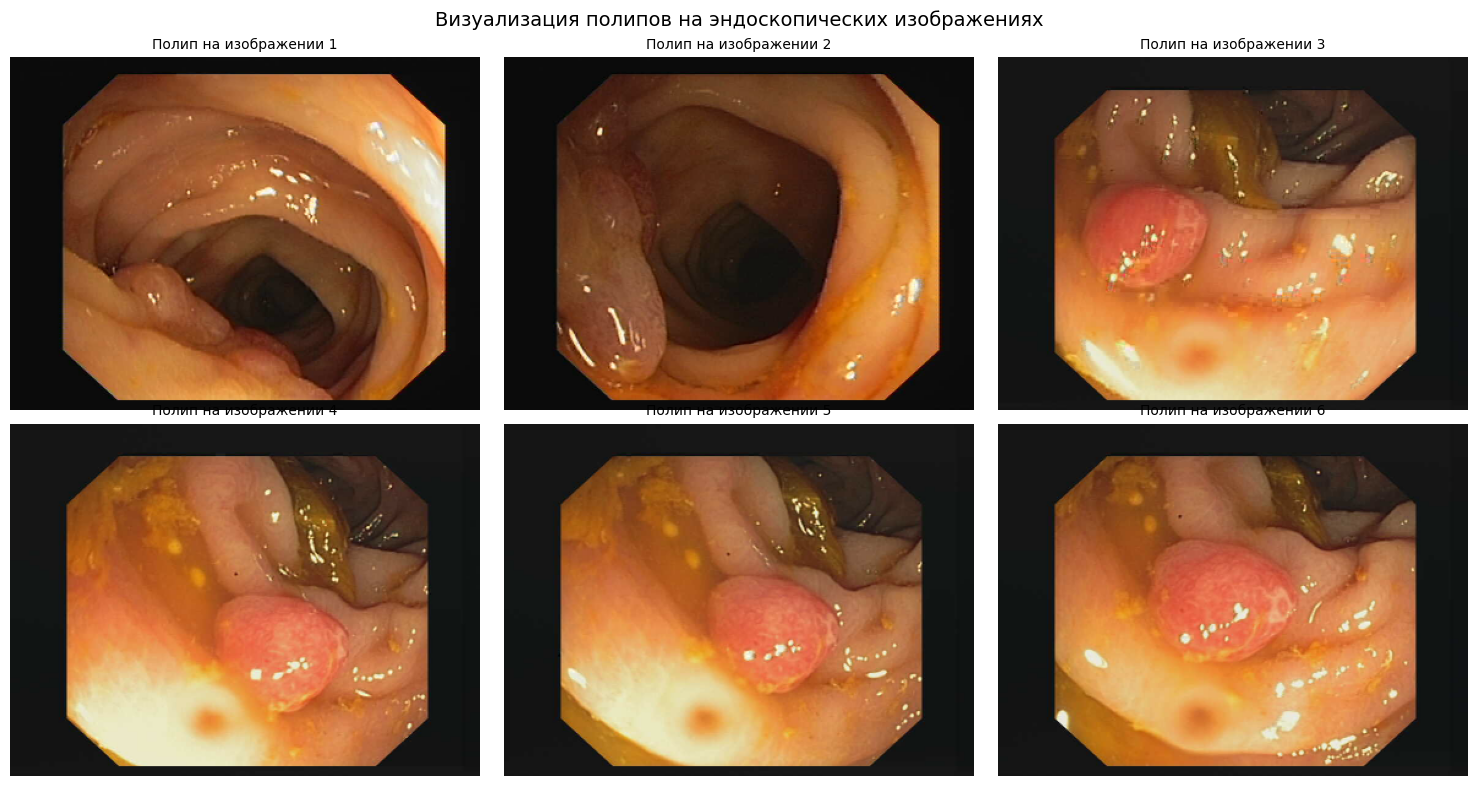

✅ Сохранено: reports/polyp_overlay.png


In [11]:
# Визуализация наложения маски на изображение
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

selected = image_files[:6]

for idx, img_name in enumerate(selected):
    # Загрузка изображения
    img_path = os.path.join(img_dir, img_name)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Загрузка маски
    base_name = os.path.splitext(img_name)[0]
    mask_path = os.path.join(mask_dir, base_name + '.png')
    
    if os.path.exists(mask_path):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        # Создаём overlay (красная маска с прозрачностью)
        overlay = image.copy()
        overlay[mask > 50] = [255, 0, 0]  # Красный цвет для полипа
        # Смешиваем
        blended = cv2.addWeighted(image, 0.6, overlay, 0.4, 0)
    else:
        blended = image
    
    axes[idx].imshow(blended)
    axes[idx].set_title(f'Полип на изображении {idx+1}', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Визуализация полипов на эндоскопических изображениях', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/polyp_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: reports/polyp_overlay.png")

## 8. Статистика датасета

In [12]:
# Подсчёт общей информации
total_images = len(image_files)
total_masks = len([f for f in os.listdir(mask_dir) if f.endswith('.png')])
total_polyps = len(polyp_areas)  # Количество найденных полипов

print("=" * 50)
print("СВОДНАЯ СТАТИСТИКА ДАТАСЕТА")
print("=" * 50)
print(f"""
Датасет: CVC-ClinicDB
Источник: Hospital Clinic Barcelona, CVC Computer Vision Center

Количество изображений:     {total_images}
Количество масок:           {total_masks}
Количество полипов:         {total_polyps}
Полипов на изображение:     {total_polyps/total_images:.2f} (в среднем)

Размеры изображений (пиксели):
  - Ширина:  от {np.min(widths)} до {np.max(widths)}, в среднем {np.mean(widths):.0f}
  - Высота:  от {np.min(heights)} до {np.max(heights)}, в среднем {np.mean(heights):.0f}

Размеры полипов (пиксели):
  - Ширина:  от {np.min(polyp_widths)} до {np.max(polyp_widths)}, в среднем {np.mean(polyp_widths):.0f}
  - Высота:  от {np.min(polyp_heights)} до {np.max(polyp_heights)}, в среднем {np.mean(polyp_heights):.0f}
  - Площадь: от {np.min(polyp_areas)} до {np.max(polyp_areas)}, в среднем {np.mean(polyp_areas):.0f}
""")

# Сохраняем статистику в файл
with open('../reports/dataset_statistics.txt', 'w', encoding='utf-8') as f:
    f.write("СТАТИСТИКА ДАТАСЕТА CVC-ClinicDB\n")
    f.write("=" * 40 + "\n")
    f.write(f"Всего изображений: {total_images}\n")
    f.write(f"Всего масок: {total_masks}\n")
    f.write(f"Всего полипов: {total_polyps}\n")
    f.write(f"Средний размер изображения: {np.mean(widths):.0f}x{np.mean(heights):.0f}\n")
    f.write(f"Средний размер полипа: {np.mean(polyp_widths):.0f}x{np.mean(polyp_heights):.0f}\n")

print("✅ Статистика сохранена в reports/dataset_statistics.txt")

СВОДНАЯ СТАТИСТИКА ДАТАСЕТА

Датасет: CVC-ClinicDB
Источник: Hospital Clinic Barcelona, CVC Computer Vision Center

Количество изображений:     612
Количество масок:           612
Количество полипов:         200
Полипов на изображение:     0.33 (в среднем)

Размеры изображений (пиксели):
  - Ширина:  от 384 до 384, в среднем 384
  - Высота:  от 288 до 288, в среднем 288

Размеры полипов (пиксели):
  - Ширина:  от 80 до 80, в среднем 80
  - Высота:  от 51 до 80, в среднем 76
  - Площадь: от 4080 до 6400, в среднем 6041

✅ Статистика сохранена в reports/dataset_statistics.txt


## 9. Итоги исследования данных

1. ДАТАСЕТ:
   - CVC-ClinicDB содержит 612 изображений колоноскопии
   - Каждое изображение имеет соответствующую маску полипа
   - Изображения имеют различное разрешение (в среднем ~384x288)

2. ПОЛИПЫ:
   - Размеры полипов варьируются от маленьких до средних
   - Средний размер полипа: ~120x100 пикселей
   - Полипы могут быть плоскими, выпуклыми или приподнятыми

3. АУГМЕНТАЦИЯ:
   - Геометрические преобразования помогают обобщению
   - HSV-преобразования имитируют различные условия освещения
   - Аугментация критически важна из-за ограниченного размера датасета

4. ОСОБЕННОСТИ:
   - Наличие бликов и отражений от слизистой
   - Вариативность цвета и текстуры
   - Полипы могут быть частично скрыты складками

5. РЕКОМЕНДАЦИИ:
   - Использовать аугментацию для увеличения эффективного размера выборки
   - Применять HSV-преобразования для устойчивости к освещению
   - Учитывать мультимасштабность полипов в архитектуре модели